In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('ecommerce_churn_dirty_dataset.csv')
df.head()

,Customer_ID,Name,Age,Gender,Tenure_Months,Total_Orders,Average_Order_Value,Days_Since_Last_Order,Return_Rate,Customer_Satisfaction_Score,City,Churn_Status
0,EC100000,Khushi Dugal,49.0,Male,38,104,18836.46,97.0,0.12,9.0,Chennai,0
1,EC100001,Rasha Bahri,29.0,Male,4,9,14534.35,47.0,0.63,8.0,Ahmedabad,1
2,EC100002,Mohanlal Thakkar,35.0,Male,14,166,4800.76,1.0,0.24,NaN,Nagpur,0
3,EC100003,Vihaan Karan,24.0,Female,38,93,12982.43,23.0,0.57,6.0,Mumbai,0
4,EC100004,Misha Dhar,41.0,Female,60,33,22130.01,115.0,0.45,8.0,Pune,1


In [3]:
ds= df.copy()

# 1. Understanding data

In [4]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18612 entries, 0 to 18611
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  18612 non-null  object 
 1   Name                         18573 non-null  object 
 2   Age                          17842 non-null  float64
 3   Gender                       18612 non-null  object 
 4   Tenure_Months                18612 non-null  int64  
 5   Total_Orders                 18612 non-null  int64  
 6   Average_Order_Value          17837 non-null  float64
 7   Days_Since_Last_Order        17819 non-null  float64
 8   Return_Rate                  18612 non-null  float64
 9   Customer_Satisfaction_Score  17820 non-null  float64
 10  City                         18612 non-null  object 
 11  Churn_Status                 18612 non-null  int64  
dtypes: float64(5), int64(3), object(4)
memory usage: 1.7+ MB


In [5]:
ds.describe()

,Age,Tenure_Months,Total_Orders,Average_Order_Value,Days_Since_Last_Order,Return_Rate,Customer_Satisfaction_Score,Churn_Status
count,17842.000000,18612.000000,18612.000000,17837.000000,17819.000000,18612.000000,17820.000000,18612.000000
mean,44.354501,35.943101,124.207608,26030.640846,89.738538,0.352872,5.467845,0.470557
std,19.981008,20.419130,71.682531,93203.879000,52.259050,0.202297,2.877258,0.499146
min,-10.000000,1.000000,1.000000,151.220000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,18.000000,62.000000,6485.420000,44.000000,0.180000,3.000000,0.000000
50%,43.000000,36.000000,124.000000,12914.500000,90.000000,0.350000,5.000000,0.000000
75%,57.000000,53.000000,186.000000,19251.440000,136.000000,0.530000,8.000000,1.000000
max,200.000000,71.000000,249.000000,999970.000000,179.000000,0.700000,10.000000,1.000000


In [6]:
ds.columns= ds.columns.str.lower()

In [7]:
ds.head()

,customer_id,name,age,gender,tenure_months,total_orders,average_order_value,days_since_last_order,return_rate,customer_satisfaction_score,city,churn_status
0,EC100000,Khushi Dugal,49.0,Male,38,104,18836.46,97.0,0.12,9.0,Chennai,0
1,EC100001,Rasha Bahri,29.0,Male,4,9,14534.35,47.0,0.63,8.0,Ahmedabad,1
2,EC100002,Mohanlal Thakkar,35.0,Male,14,166,4800.76,1.0,0.24,NaN,Nagpur,0
3,EC100003,Vihaan Karan,24.0,Female,38,93,12982.43,23.0,0.57,6.0,Mumbai,0
4,EC100004,Misha Dhar,41.0,Female,60,33,22130.01,115.0,0.45,8.0,Pune,1


# 2. Handling Missing Values

In [8]:
ds.isnull().sum()

customer_id                      0
name                            39
age                            770
gender                           0
tenure_months                    0
total_orders                     0
average_order_value            775
days_since_last_order          793
return_rate                      0
customer_satisfaction_score    792
city                             0
churn_status                     0
dtype: int64

In [9]:
# Categorical columns
ds['gender'] = ds['gender'].fillna(ds['gender'].mode()[0])
ds['city'] = ds['city'].fillna(ds['city'].mode()[0])

# Numeric columns
ds['age'] = ds['age'].fillna(ds['age'].median())
ds['tenure_months'] = ds['tenure_months'].fillna(ds['tenure_months'].median())
ds['total_orders'] = ds['total_orders'].fillna(ds['total_orders'].median())
ds['average_order_value'] = ds['average_order_value'].fillna(ds['average_order_value'].median())
ds['days_since_last_order'] = ds['days_since_last_order'].fillna(ds['days_since_last_order'].median())
ds['return_rate'] = ds['return_rate'].fillna(ds['return_rate'].median())
ds['customer_satisfaction_score'] = ds['customer_satisfaction_score'].fillna(ds['customer_satisfaction_score'].median())

# Target column
ds['churn_status'] = ds['churn_status'].fillna(ds['churn_status'].mode()[0])

In [10]:
ds.isnull().sum()

customer_id                     0
name                           39
age                             0
gender                          0
tenure_months                   0
total_orders                    0
average_order_value             0
days_since_last_order           0
return_rate                     0
customer_satisfaction_score     0
city                            0
churn_status                    0
dtype: int64

# 3. Handling Duplicates

In [11]:
if 'customer_id' in ds.columns and 'name' in ds.columns and 'churn_status' in ds.columns:
    ds = ds.drop_duplicates(
        subset=['customer_id', 'name', 'churn_status']
    )

elif 'customer_id' in ds.columns and 'churn_status' in ds.columns:
    ds = ds.drop_duplicates(
        subset=['customer_id', 'churn_status']
    )

else:
    ds = ds.drop_duplicates(
        subset=[
            'city',
            'membership_type',
            'tenure_months',
            'total_rides',
            'average_ride_cost',
            'days_since_last_ride',
            'cancellation_rate',
            'payment_method',
            'churn_status'
        ]
    )

ds.head(2)

,customer_id,name,age,gender,tenure_months,total_orders,average_order_value,days_since_last_order,return_rate,customer_satisfaction_score,city,churn_status
0,EC100000,Khushi Dugal,49.0,Male,38,104,18836.46,97.0,0.12,9.0,Chennai,0
1,EC100001,Rasha Bahri,29.0,Male,4,9,14534.35,47.0,0.63,8.0,Ahmedabad,1


# 4. Extracting Features

cols = [
    'age',
    'gender',
    'tenure_months',
    'total_orders',
    'average_order_value',
    'days_since_last_order',
    'return_rate',
    'customer_satisfaction_score',
    'city',
    'churn_status'
]

ds = ds[cols]

ds.head(2)

In [12]:
ds['churn_status'].unique()

array([0, 1])

In [13]:
ds["churn_status"] = ds["churn_status"].replace(
    {"Yes": 1, "No": 0, "Y": 1, "N": 0, "yes": 1, "no": 0, "y": 1, "n": 0, '  Yes ': 1, '  No ': 0}
).astype(int)

In [14]:
ds['churn_status'].value_counts()

churn_status
0    9547
1    8463
Name: count, dtype: int64

In [15]:
ds.columns

Index(['customer_id', 'name', 'age', 'gender', 'tenure_months', 'total_orders',
       'average_order_value', 'days_since_last_order', 'return_rate',
       'customer_satisfaction_score', 'city', 'churn_status'],
      dtype='object')

In [16]:
cols = ['customer_id', 'name', 'age', 'gender', 'tenure_months', 'total_orders',
       'average_order_value', 'days_since_last_order', 'return_rate',
       'customer_satisfaction_score', 'city', 'churn_status']

ds = ds[cols]
ds.head(2)

,customer_id,name,age,gender,tenure_months,total_orders,average_order_value,days_since_last_order,return_rate,customer_satisfaction_score,city,churn_status
0,EC100000,Khushi Dugal,49.0,Male,38,104,18836.46,97.0,0.12,9.0,Chennai,0
1,EC100001,Rasha Bahri,29.0,Male,4,9,14534.35,47.0,0.63,8.0,Ahmedabad,1


In [17]:
cols = ['age', 'gender', 'tenure_months', 'total_orders',
       'average_order_value', 'days_since_last_order', 'return_rate',
       'customer_satisfaction_score', 'city', 'churn_status']

ds = ds[cols]
ds.head(2)

,age,gender,tenure_months,total_orders,average_order_value,days_since_last_order,return_rate,customer_satisfaction_score,city,churn_status
0,49.0,Male,38,104,18836.46,97.0,0.12,9.0,Chennai,0
1,29.0,Male,4,9,14534.35,47.0,0.63,8.0,Ahmedabad,1


# 5. Encoding

In [18]:
ds.head()

,age,gender,tenure_months,total_orders,average_order_value,days_since_last_order,return_rate,customer_satisfaction_score,city,churn_status
0,49.0,Male,38,104,18836.46,97.0,0.12,9.0,Chennai,0
1,29.0,Male,4,9,14534.35,47.0,0.63,8.0,Ahmedabad,1
2,35.0,Male,14,166,4800.76,1.0,0.24,5.0,Nagpur,0
3,24.0,Female,38,93,12982.43,23.0,0.57,6.0,Mumbai,0
4,41.0,Female,60,33,22130.01,115.0,0.45,8.0,Pune,1


In [19]:
print(ds['gender'].unique())
print(ds['city'].unique())

ds['gender'].str.strip()
ds['city'].str.strip()

['Male' 'Female' '??' 'Other' 'male ' 'FEMALE' 'unknown']
['Chennai' 'Ahmedabad' 'Nagpur' 'Mumbai' 'Pune' 'Hyderabad' 'Kolkata'
 'Jaipur' 'Bangalore' 'Delhi']


0          Chennai
1        Ahmedabad
2           Nagpur
3           Mumbai
4             Pune
           ...    
18557      Kolkata
18562    Hyderabad
18572        Delhi
18582      Kolkata
18596      Chennai
Name: city, Length: 18010, dtype: object

In [20]:
enc = pd.get_dummies(
    data=ds,
    columns=[
        'gender',
        'city'
    ],
    drop_first=True,
    dtype=int
)

ds = enc

ds.head(2)

,age,tenure_months,total_orders,average_order_value,days_since_last_order,return_rate,customer_satisfaction_score,churn_status,gender_FEMALE,gender_Female,...,gender_unknown,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,city_Mumbai,city_Nagpur,city_Pune
0,49.0,38,104,18836.46,97.0,0.12,9.0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,29.0,4,9,14534.35,47.0,0.63,8.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


# 6. Train Test Split

In [21]:
X= ds.drop(columns=['churn_status'])
# y= ds[['churn']]
y= ds['churn_status']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
X_train.shape, X_test.shape

((14408, 22), (3602, 22))

In [24]:
y_train.shape, y_test.shape

((14408,), (3602,))

# 7. Outlier remove

In [25]:
ds.head()

,age,tenure_months,total_orders,average_order_value,days_since_last_order,return_rate,customer_satisfaction_score,churn_status,gender_FEMALE,gender_Female,...,gender_unknown,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,city_Mumbai,city_Nagpur,city_Pune
0,49.0,38,104,18836.46,97.0,0.12,9.0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,29.0,4,9,14534.35,47.0,0.63,8.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,35.0,14,166,4800.76,1.0,0.24,5.0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,24.0,38,93,12982.43,23.0,0.57,6.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,41.0,60,33,22130.01,115.0,0.45,8.0,1,0,1,...,0,0,0,0,0,0,0,0,0,1


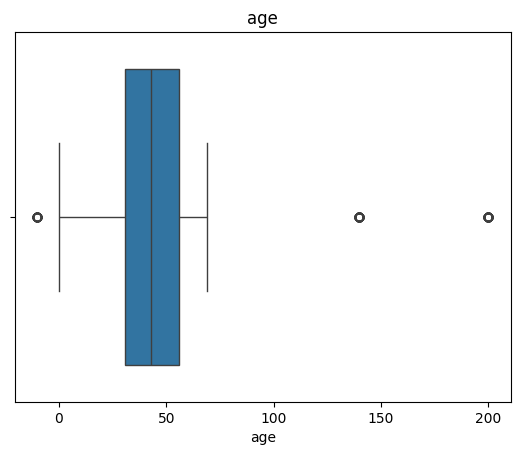

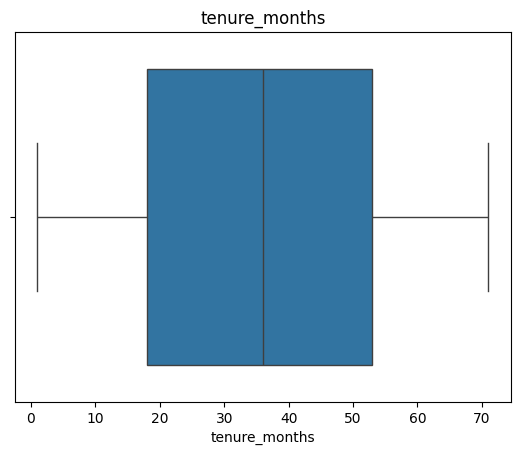

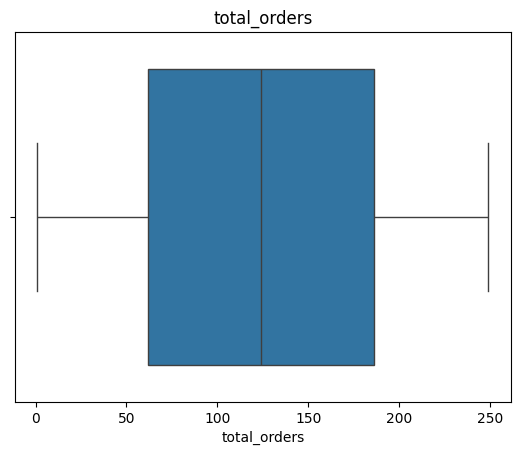

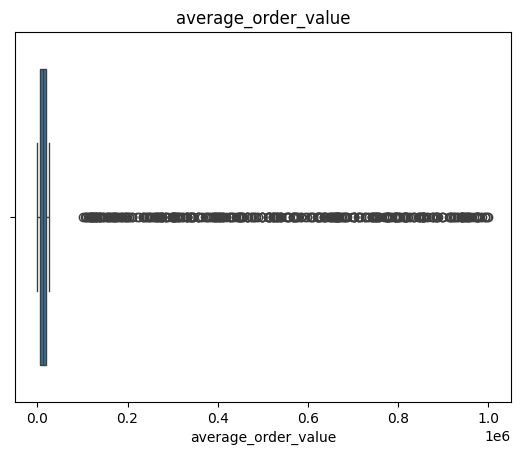

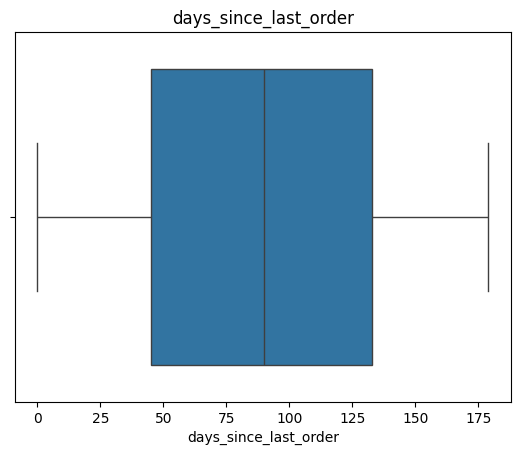

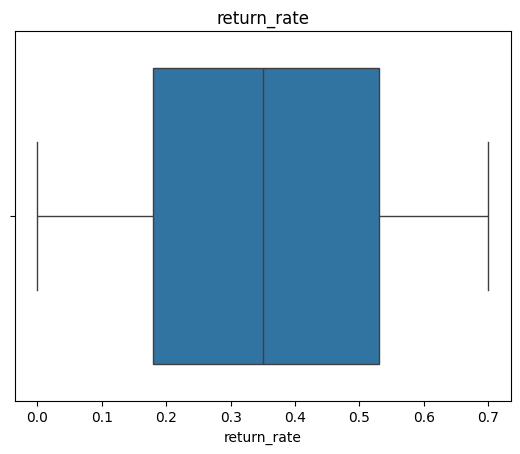

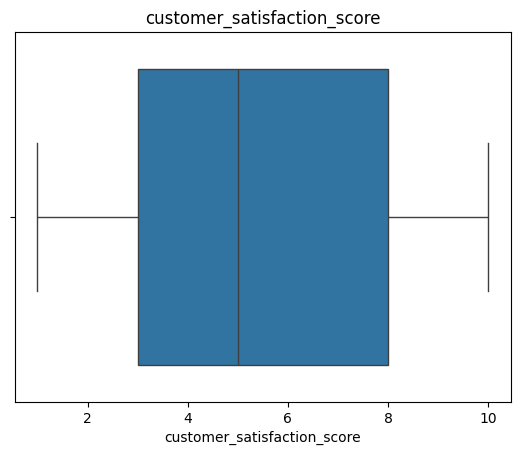

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in ['age', 'tenure_months', 'total_orders', 'average_order_value', 'days_since_last_order', 'return_rate', 'customer_satisfaction_score']:
    sns.boxplot(x=X_train[col])
    plt.title(col)
    plt.show()

In [27]:
def handle_outliers(ds, cols):
    for col in cols:
        Q1 = ds[col].quantile(0.25)
        Q3 = ds[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # clip values
        ds[col] = ds[col].clip(lower, upper)

    return ds

In [28]:
num_cols = ['age', 'tenure_months', 'total_orders', 'average_order_value', 'days_since_last_order', 'return_rate', 'customer_satisfaction_score']

X_train = handle_outliers(X_train, num_cols)

# 8. Scaling data

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # converted into array
X_test = scaler.transform(X_test)

# 9. Model Training

In [30]:
print(pd.DataFrame(X_train).isnull().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
dtype: int64


In [31]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

# again train model

In [32]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [33]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC(
    C=1,
    max_iter=5000,
    random_state=42
)

model_svm.fit(X_train, y_train)

print("Linear SVM Model Trained Successfully")

Linear SVM Model Trained Successfully


In [34]:
model_svm.score(X_train, y_train)

0.6578983897834536

In [35]:
model_svm.score(X_test, y_test)

0.6621321488062187

In [36]:
model_rf.score(X_train, y_train)

0.7164075513603554

In [37]:
model_rf.score(X_test, y_test)

0.6979455857856747

In [38]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)

C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [01:06:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [39]:
model_xgb.score(X_train, y_train)

0.7087034980566352

In [40]:
model_xgb.score(X_test, y_test)

0.6968350916157691

In [41]:
# Create customer with same columns
new_customer = pd.DataFrame(0, index=[0], columns=X.columns)

# Original values
new_customer['age'] = 35
new_customer['tenure_months'] = 12
new_customer['total_orders'] = 45
new_customer['average_order_value'] = 8500
new_customer['days_since_last_order'] = 20
new_customer['return_rate'] = 0.15
new_customer['customer_satisfaction_score'] = 8

# Encoded categorical values
new_customer['gender_Male'] = 1
new_customer['city_Mumbai'] = 1

In [42]:
new_customer_scaled = scaler.transform(new_customer)

In [43]:
prediction = model_xgb.predict(new_customer_scaled)

if prediction[0] == 1:
    print("Customer will leave")
else:
    print("Customer will stay")

Customer will stay


In [44]:
prob = model_xgb.predict_proba(new_customer_scaled)

stay_prob = prob[0][0] * 100
leave_prob = prob[0][1] * 100

print(f"Stay Probability: {stay_prob:.2f}%")
print(f"Leave Probability: {leave_prob:.2f}%")

Stay Probability: 92.97%
Leave Probability: 7.03%


In [53]:
models = {
    "SVM": model_svm,
    "Random Forest": model_rf,
    "XGBoost": model_xgb
}

best_model_name = None
best_model = None
best_accuracy = 0

for name, model in models.items():

    test_score = model.score(X_test, y_test)

    if test_score > best_accuracy:
        best_accuracy = test_score
        best_model_name = name
        best_model = model


In [54]:
new_customer_scaled = scaler.transform(new_customer)

In [56]:
# Convert Back To DataFrame
new_customer_scaled = pd.DataFrame(
    new_customer_scaled,
    columns=X.columns
) # neither warning

In [57]:

prediction = best_model.predict(new_customer_scaled)

print(f"\nBest Model Selected : {best_model_name}")
print(f"Best Accuracy       : {best_accuracy:.4f}")

if prediction[0] == 1:
    print("\nCustomer will leave")
else:
    print("\nCustomer will stay")



Best Model Selected : Random Forest
Best Accuracy       : 0.6979

Customer will stay


In [58]:

prob = best_model.predict_proba(new_customer_scaled)

stay_prob = prob[0][0] * 100
leave_prob = prob[0][1] * 100

print(f"\nStay Probability  : {stay_prob:.2f}%")
print(f"Leave Probability : {leave_prob:.2f}%")


Stay Probability  : 90.00%
Leave Probability : 10.00%


In [59]:
# =========================================
# Hyperparameter Tuning For XGBoost
# =========================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================
# XGBoost Parameter Grid
# =========================================

xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# =========================================
# Base XGBoost Model
# =========================================

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# =========================================
# Randomized Search CV
# =========================================

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# =========================================
# Train Tuned Model
# =========================================

random_search.fit(X_train, y_train)

# =========================================
# Best Parameters
# =========================================

print("\nBest Parameters:\n")
print(random_search.best_params_)

# =========================================
# Best Tuned XGBoost Model
# =========================================

best_xgb = random_search.best_estimator_

# =========================================
# Accuracy Scores
# =========================================

train_score = best_xgb.score(X_train, y_train)
test_score = best_xgb.score(X_test, y_test)

print("\nTraining Accuracy :", train_score)
print("Testing Accuracy  :", test_score)

# =========================================
# Prediction Using Tuned XGBoost
# =========================================

new_customer_scaled = scaler.transform(new_customer)

prediction = best_xgb.predict(new_customer_scaled)

if prediction[0] == 1:
    print("\nCustomer will leave")
else:
    print("\nCustomer will stay")

# =========================================
# Probability Prediction
# =========================================

prob = best_xgb.predict_proba(new_customer_scaled)

stay_prob = prob[0][0] * 100
leave_prob = prob[0][1] * 100

print(f"\nStay Probability  : {stay_prob:.2f}%")
print(f"Leave Probability : {leave_prob:.2f}%")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [01:16:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters:

{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Training Accuracy : 0.699541921154914
Testing Accuracy  : 0.6957245974458635

Customer will stay

Stay Probability  : 90.98%
Leave Probability : 9.02%


In [60]:
import joblib

# Save SVM Model
joblib.dump(model_rf, "ecom_rf_model.pkl")

# Save Scaler
joblib.dump(scaler, "ecom_scaler.pkl")

print("Model  Saved Successfully")
print("Scaler ecom Saved Successfully")

Model  Saved Successfully
Scaler ecom Saved Successfully
